In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import math
from matplotlib.lines import Line2D

Z_975 = 1.959963984540054  # 95% CI

# Panel D

In [2]:
df=pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx', index_col=0)

In [3]:
df=df.loc[~df.Date_start_HDM.isna()].copy()
df=df[df['Obs_time']>2].copy()

In [4]:
timeline=df.sort_values('Obs_time', ascending=False).copy()
timeline['t']=timeline['Obs_time']

In [5]:
# Get time to PD, exitus or withdrawal events
timeline['Dias_hasta_progresion']=np.nan
timeline.loc[timeline['PD_event']==1, 'Dias_hasta_progresion']=timeline.loc[timeline['PD_event']==1].t

timeline['Dias_hasta_exitus']=np.nan
timeline.loc[timeline['Exitus']==1, 'Dias_hasta_exitus']=timeline.loc[timeline['Exitus']==1].t

timeline['Dias_hasta_salida']=np.nan
timeline.loc[timeline['Withdrawal']==1, 'Dias_hasta_salida']=timeline.loc[timeline['Withdrawal']==1].t



In [6]:
# Set status of each subject
timeline['Status']='Ongoing'

timeline.loc[~timeline.Dias_hasta_salida.isna(),'Status']='Voluntary Withdrawal'
timeline.loc[~timeline.Dias_hasta_exitus.isna(),'Status']='Exitus'

timeline=timeline.reset_index()

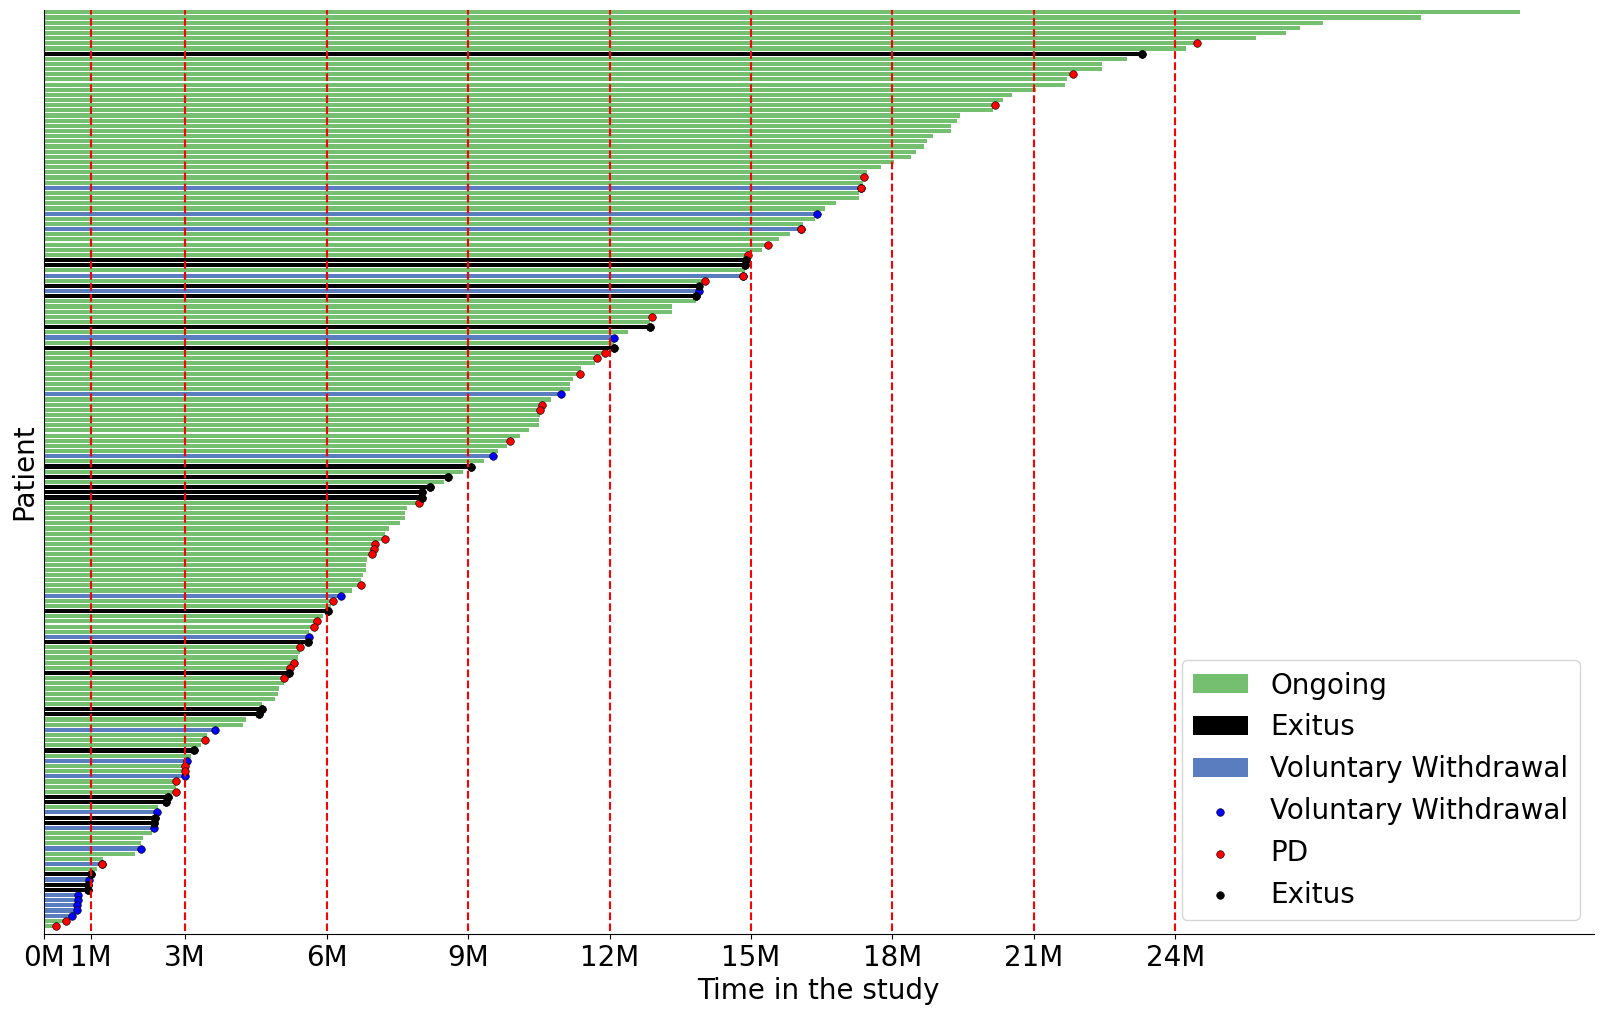

In [7]:
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 20

# Get first 2 colors from the 'muted' palette
base_colors = [sns.color_palette("muted", 3)[2]]+ [(0, 0, 0)]+[sns.color_palette("muted", 3)[0]]#sns.color_palette("muted", 2)
# Add black as the third color
custom_palette = base_colors   # RGB tuple for black

sns.barplot(timeline, x='t', y=timeline.index.astype('category'), hue='Status', dodge=False, palette=custom_palette)

sns.scatterplot(timeline, x='Dias_hasta_salida', y=timeline.index.astype('category'), color='blue', s=30, label='Voluntary Withdrawal', edgecolor='k')
sns.scatterplot(timeline, x='Dias_hasta_progresion', y=timeline.index.astype('category'), color='red', s=30, label='PD', edgecolor='k')
sns.scatterplot(timeline, x='Dias_hasta_exitus', y=timeline.index.astype('category'), color='k', s=30, label='Exitus', edgecolor='k')


plt.xticks(rotation=0, ticks=[0,30,90,180,270,360,450,540,630,720], labels=['0M','1M','3M','6M','9M','12M','15M','18M','21M','24M']);
plt.ylabel('Patient')
plt.xlabel('Time in the study')

plt.vlines([30,90,180,270,360,450,540,630,720],-1,178,linestyles='--', colors='r')
plt.ylim([178.5,-0.5])
plt.yticks(plt.gca().get_yticks(),labels=[])

plt.yticks([])

sns.despine()

#plt.savefig('Swimmers.svg')


# Panel E

In [8]:
def km_fit(time, event):
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=int)
    order = np.argsort(time)
    t = time[order]
    e = event[order]
    times_event = np.unique(t[e == 1])
    S = 1.0
    greenwood = 0.0
    surv, var = [], []

    for ti in times_event:
        n_risk = np.sum(t >= ti)
        d = np.sum((t == ti) & (e == 1))
        if n_risk <= 0:
            continue
        S *= (1.0 - d / n_risk)
        if n_risk - d > 0:
            greenwood += d / (n_risk * (n_risk - d))
        surv.append(S)
        var.append((S ** 2) * greenwood)

    times_event = np.array(times_event, dtype=float)
    surv = np.array(surv, dtype=float)

    # log(-log) CI
    eps = 1e-12
    var = np.array(var, dtype=float)
    se = np.sqrt(var)
    S_clip = np.clip(surv, eps, 1 - eps)
    loglog = np.log(-np.log(S_clip))
    se_loglog = se / (S_clip * np.abs(np.log(S_clip)))
    lower = np.exp(-np.exp(loglog + Z_975 * se_loglog))
    upper = np.exp(-np.exp(loglog - Z_975 * se_loglog))

    # step arrays include t=0
    step_t = np.concatenate([[0.0], times_event])
    step_S = np.concatenate([[1.0], surv])
    step_lo = np.concatenate([[1.0], lower])
    step_hi = np.concatenate([[1.0], upper])

    return {
        "times_event": times_event,
        "surv": surv,
        "lower": lower,
        "upper": upper,
        "step_t": step_t,
        "step_S": step_S,
        "step_lo": step_lo,
        "step_hi": step_hi
    }

In [9]:
def extend_to_xend(km, x_end):
    x_end = float(x_end)
    if km["step_t"][-1] < x_end:
        km["step_t"]  = np.append(km["step_t"],  x_end)
        km["step_S"]  = np.append(km["step_S"],  km["step_S"][-1])
        km["step_lo"] = np.append(km["step_lo"], km["step_lo"][-1])
        km["step_hi"] = np.append(km["step_hi"], km["step_hi"][-1])
    return km

In [10]:
def at_risk_counts(time, ticks):
    time = np.asarray(time, dtype=float)
    return [int(np.sum(time >= tt)) for tt in ticks]

In [11]:
def surv_at_times(step_t, step_S, query_t):
    """
    Return S(t) for each query time using the step function (post).
    """
    step_t = np.asarray(step_t, dtype=float)
    step_S = np.asarray(step_S, dtype=float)
    query_t = np.asarray(query_t, dtype=float)

    # index of last step_t <= query_t
    idx = np.searchsorted(step_t, query_t, side="right") - 1
    idx = np.clip(idx, 0, len(step_S) - 1)
    return step_S[idx]

In [12]:
def plot_km_fulltail_with_censors(time, event, title, label,
                                 step_days=180, out_png=None, out_pdf=None,
                                 censor_label="Censored"):

    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=int)
    # End axis at max follow-up (includes late censoring)
    x_end = float(np.max(time))
    x_end_rounded = int(math.ceil(x_end / step_days) * step_days)
    ticks = list(range(0, x_end_rounded + step_days, step_days))
    km = km_fit(time, event)
    km = extend_to_xend(km, x_end_rounded)

    # Censor times and their survival values
    censor_times = time[event == 0]
    censor_y = surv_at_times(km["step_t"], km["step_S"], censor_times)

    # Figure layout
    fig = plt.figure(figsize=(7.2, 5.6), dpi=200, constrained_layout=True)
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[4.2, 1.0])

    ax = fig.add_subplot(gs[0, 0])
    ax_tbl = fig.add_subplot(gs[1, 0])
    ax_tbl.axis("off")

    # KM curve + CI
    line = ax.step(km["step_t"], km["step_S"], where="post")[0]
    ax.fill_between(km["step_t"], km["step_lo"], km["step_hi"], step="post", alpha=0.2)

    # Censor marks: vertical ticks '|'
    ax.plot(censor_times, censor_y, linestyle="None", marker="|",
            markersize=10, markeredgewidth=1.5)

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Progression-free survival probability")
    ax.set_xlim(0, x_end_rounded)
    ax.set_ylim(0, 1.02)
    ax.set_xticks(ticks)

    # Custom legend: line + censor marker
    handles = [
        Line2D([0], [0], color=line.get_color(), lw=2, label=label),
        Line2D([0], [0], color='#ff7f0e', marker="|", linestyle="None",
               markersize=10, markeredgewidth=1.5, label=censor_label),
    ]
    ax.legend(handles=handles, loc="best", frameon=False)

    # Risk table
    counts = at_risk_counts(time, ticks)
    '''
    counts = at_risk_counts(time, ticks)
    table = ax_tbl.table(
        cellText=[counts],
        rowLabels=["At risk"],
        colLabels=[str(t) for t in ticks],
        cellLoc="center",
        rowLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.2)
    '''

    # Create secondary x-axis at bottom
    secax = ax.secondary_xaxis('bottom')
   
    # Set second row of ticks and labels
    secax.set_xticks(ticks)
    secax.set_xticklabels(counts)

    # Move it below the xlabel
    secax.spines['bottom'].set_position(('outward', 50))
    # Get secondary axis position in figure coordinates
    bbox = secax.get_position()
    mainbox=ax.get_position()
    # Add text aligned with the secondary ticks
    fig.text(
        bbox.x0+0.05 ,                 # left of ticks
        mainbox.y0 - 0.105,     # vertical center of secax
        "At risk",
        ha="right",
        va="center"
    )

    
    if out_png:
        fig.savefig(out_png, bbox_inches="tight")
    if out_pdf:
        fig.savefig(out_pdf, bbox_inches="tight")
    #plt.savefig('test.svg'    , bbox_inches="tight")
    plt.show()

 

In [13]:
df.columns

Index(['Date_start_HDM', 'DCABP_first_month', 'DCABP_general',
       'Hyper_DCABP_month_1', 'Hyper_DCABP_general', 'DCABP_switch',
       'Withdrawal', 'Exitus', 'PD_event', 'Obs_time', 'Early_PD', 'Cohort',
       'Treatment_group', 'Age', 'Ethnicity', 'Height', 'Weight', 'BMI',
       'Menopause', 'ECOG', 'Hemoglobin_g_per_dL',
       'Linfocytes_thousands_per_mm3', 'Neutrophils_thousands_per_mm3',
       'Platelets_thousands_per_mm3', 'Albumin_g_per_dL', 'Corticoids',
       'Beta_blockers', 'Opioids'],
      dtype='object')

In [14]:
event_col = 'PD_event' 
time_col  = 'Obs_time' 
cohort_col = "Cohort"


In [15]:
T = pd.to_numeric(df[time_col], errors="coerce")
E = pd.to_numeric(df[event_col], errors="coerce")

if E.dropna().dtype == bool:
    E = E.astype(int)
mask = T.notna() & E.notna()
df0 = df.loc[mask].copy()
df0["T"] = T[mask].astype(float)
df0["E"] = E[mask].astype(int)



In [16]:
step_days=180
x_end = float(np.max(df0["T"].to_numpy()))
x_end_rounded = int(math.ceil(x_end / step_days) * step_days)
ticks = list(range(0, x_end_rounded + step_days, step_days))
at_risk_counts(df0["T"].to_numpy(), ticks)

[178, 117, 66, 30, 8, 1, 0]

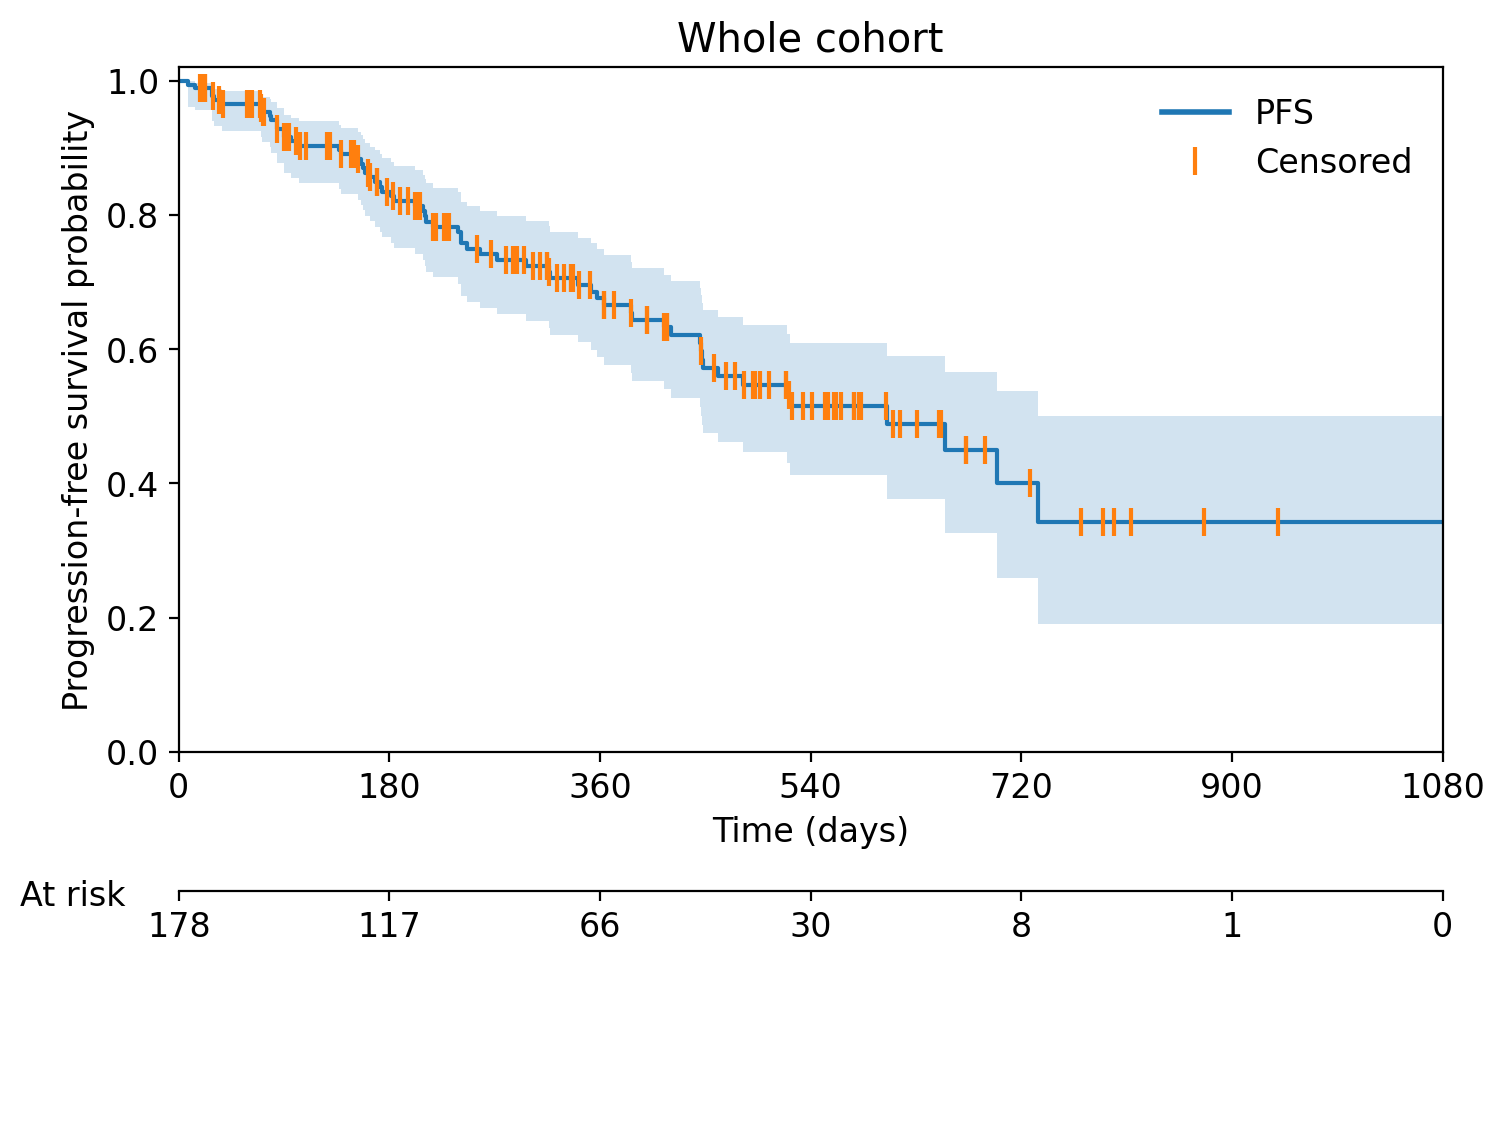

In [17]:
# ---------------------------
# GLOBAL
# ---------------------------
plt.rcParams['font.size'] = 12

plot_km_fulltail_with_censors(
    df0["T"].to_numpy(),
    df0["E"].to_numpy(),
    title="Whole cohort",
    label="PFS",
    step_days=180,
    #out_svg="PFS_KM_global_fullTail_censors.svg"
)


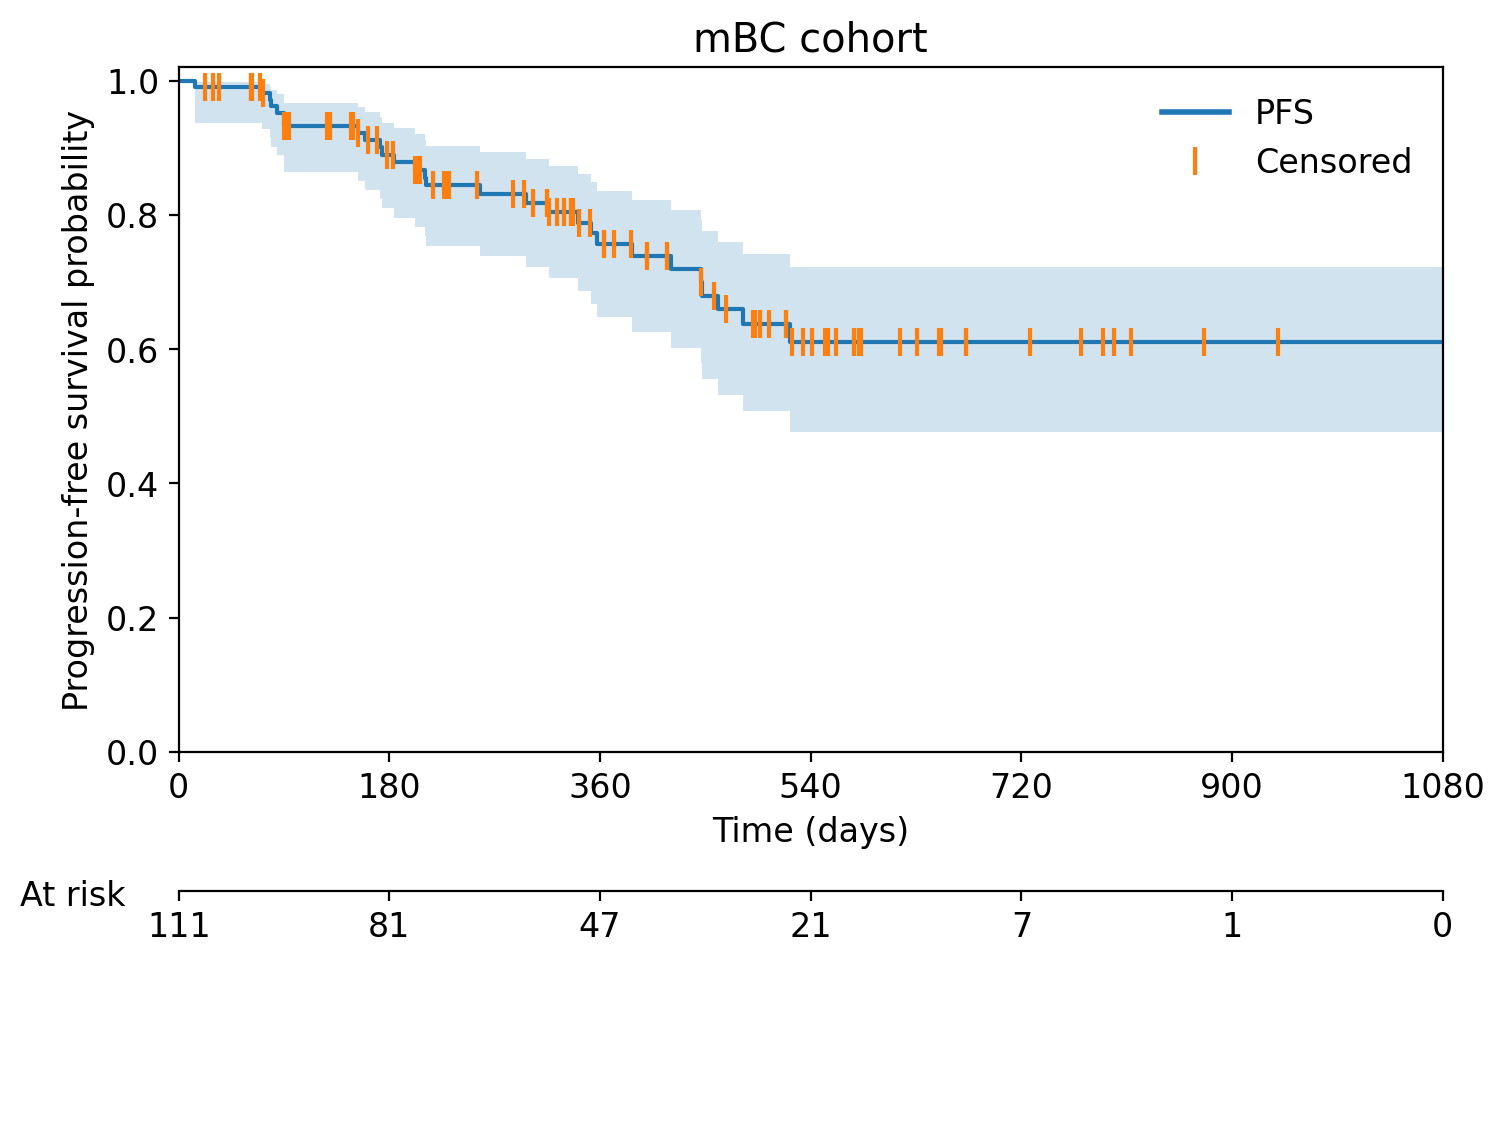

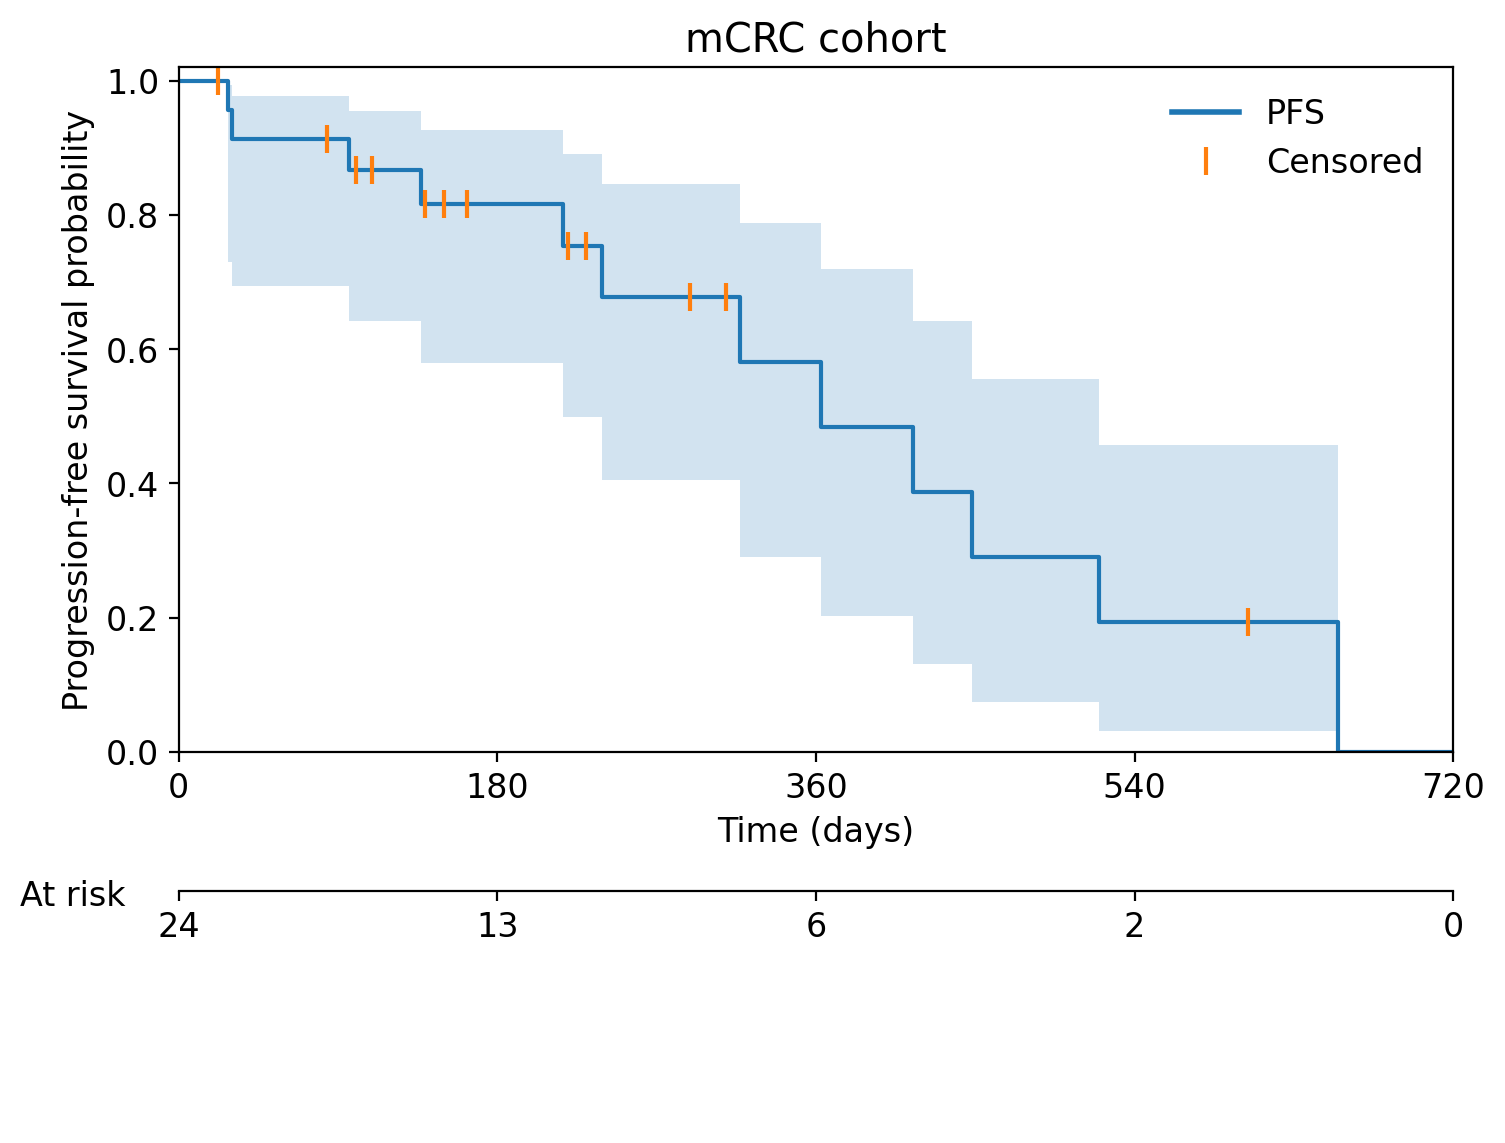

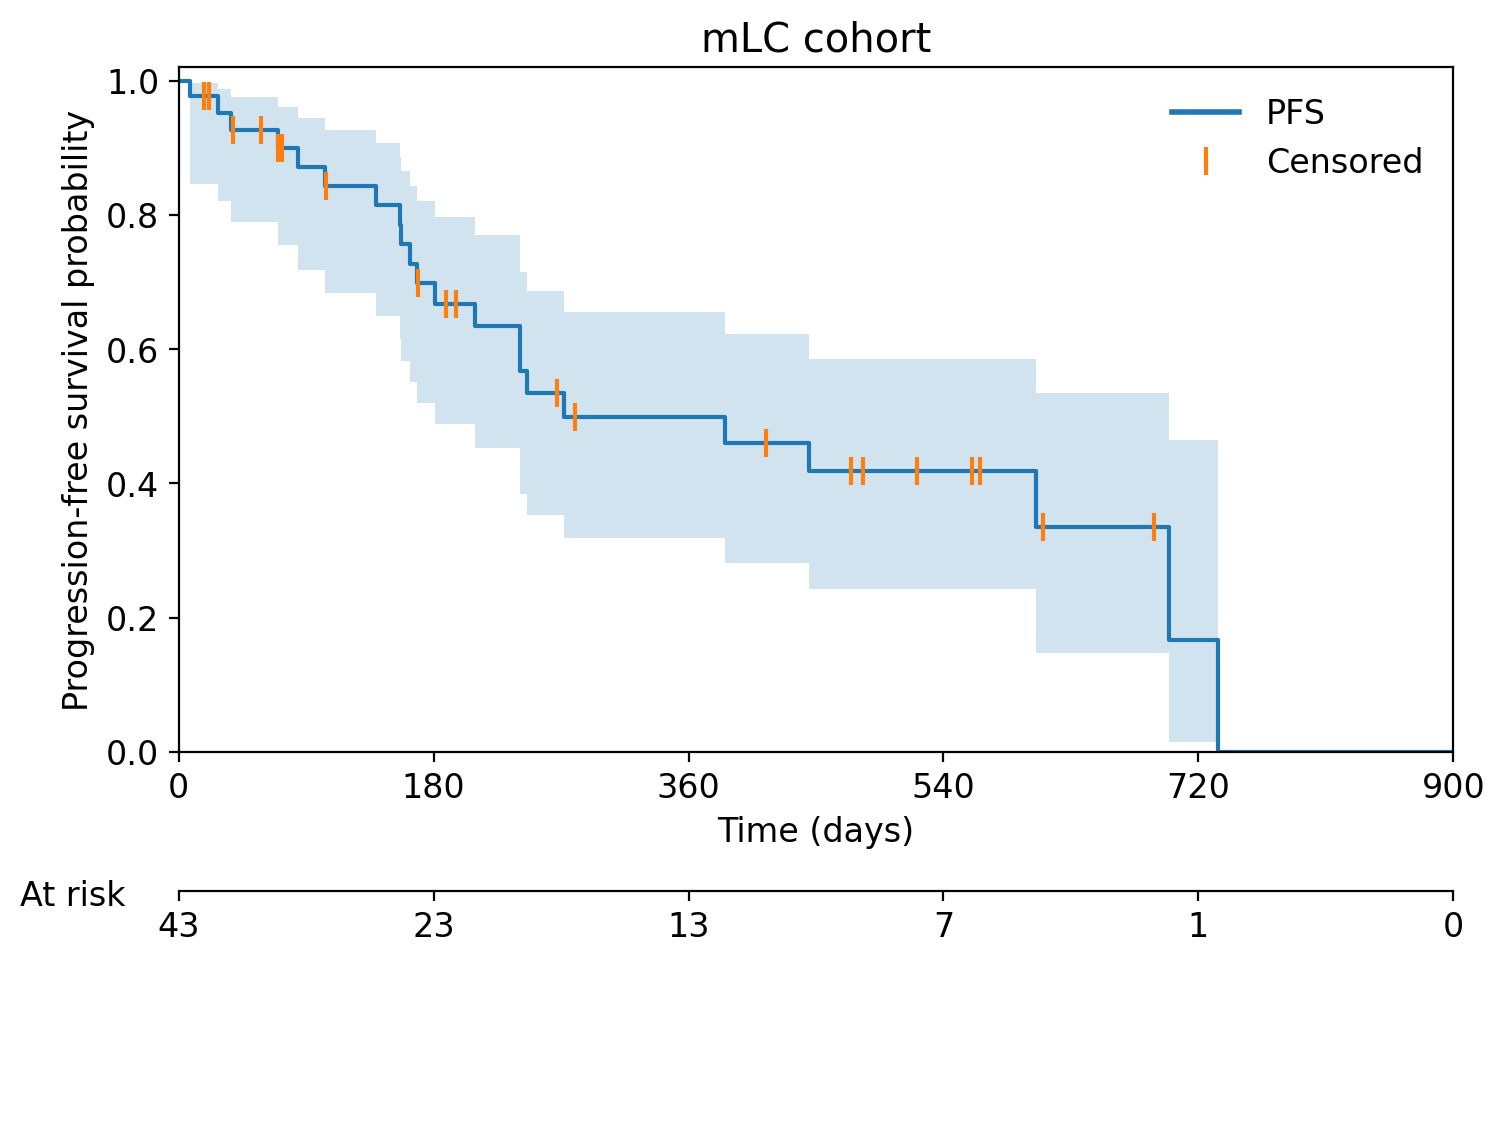

In [18]:
# ---------------------------
# BREAST / COLORECTAL / LUNG
# ---------------------------

for cohort in ["Breast", "Colorectal", "Lung"]:
    dfi = df0[df0[cohort_col] == cohort].copy()
    if cohort=='Breast':
        title_c='mBC'
    elif cohort=='Colorectal':
        title_c='mCRC'
    else:
        title_c='mLC'
    plot_km_fulltail_with_censors(
        dfi["T"].to_numpy(),
        dfi["E"].to_numpy(),
        title=f"{title_c} cohort",
        label=f"PFS",
        step_days=180,
        #out_svg=f"PFS_KM_{cohort}_fullTail_censors.svg"

    )

# Panel E

In [20]:
quality_df=pd.read_csv('../../../data/processed/data_completeness/user_quality_df.csv', index_col=0)

In [22]:
appendix_df=pd.read_csv('../../../data/processed/data_completeness/user_quality_appendix_1.csv', index_col=0)

In [23]:
quality_df=quality_df.merge(appendix_df,left_index=True, right_index=True)

In [24]:
# Number of valid days on each period
quality_df['obs_valid_90']=[90 if i>90 else i for i in quality_df.days_active]
quality_df['obs_valid_180']=[90 if i>180 else i-90 for i in quality_df.days_active]
quality_df.loc[quality_df.obs_valid_180<0, 'obs_valid_180']=0


In [25]:
# Make a temp df and compute the days with valid recordings over the total of days active on each period
df_=quality_df.copy()
df_[['hr_valid_days_90','sleep_valid_days_90',
     'steps_valid_days_90','spo2_valid_days_90',
     'location_valid_days_90','app_usage_valid_days_90']]=df_[['hr_valid_days_90','sleep_valid_days_90',
                                                               'steps_valid_days_90','spo2_valid_days_90',
                                                               'location_valid_days_90','app_usage_valid_days_90']].astype(float).div(df_.obs_valid_90.astype(float), axis=0)
df_[['hr_valid_days_91_180','sleep_valid_days_91_180','steps_valid_days_91_180',
   'spo2_valid_days_91_180','location_valid_days_91_180',
   'app_usage_valid_days_91_180']]=df_[['hr_valid_days_91_180','sleep_valid_days_91_180','steps_valid_days_91_180',
                                      'spo2_valid_days_91_180','location_valid_days_91_180',
                                      'app_usage_valid_days_91_180']].astype(float).div(df_.obs_valid_180.astype(float), axis=0)

In [26]:
# Make long form df
df_=df_[['hr_valid_days_90','sleep_valid_days_90','steps_valid_days_90','spo2_valid_days_90','app_usage_valid_days_90',
        'hr_valid_days_91_180','sleep_valid_days_91_180','steps_valid_days_91_180','spo2_valid_days_91_180','app_usage_valid_days_91_180']].melt()

df_['Data_Type']=[i.split('_valid')[0] for i in df_.variable]
df_['Period']=[i.split('valid_')[-1] for i in df_.variable]

df_.Data_Type=df_.Data_Type.replace({'hr':'Heart Rate','sleep':'Sleep','spo2':'SpO2','app_usage':'Phone Use','steps':'Steps'})
df_.Period=df_.Period.replace({'days_90':'Days 1 to 90','days_91_180':'Days 91 to 180'})

In [27]:
df_['value']=(df_['value'])*100


Text(0.5, 44.7222222222222, '')

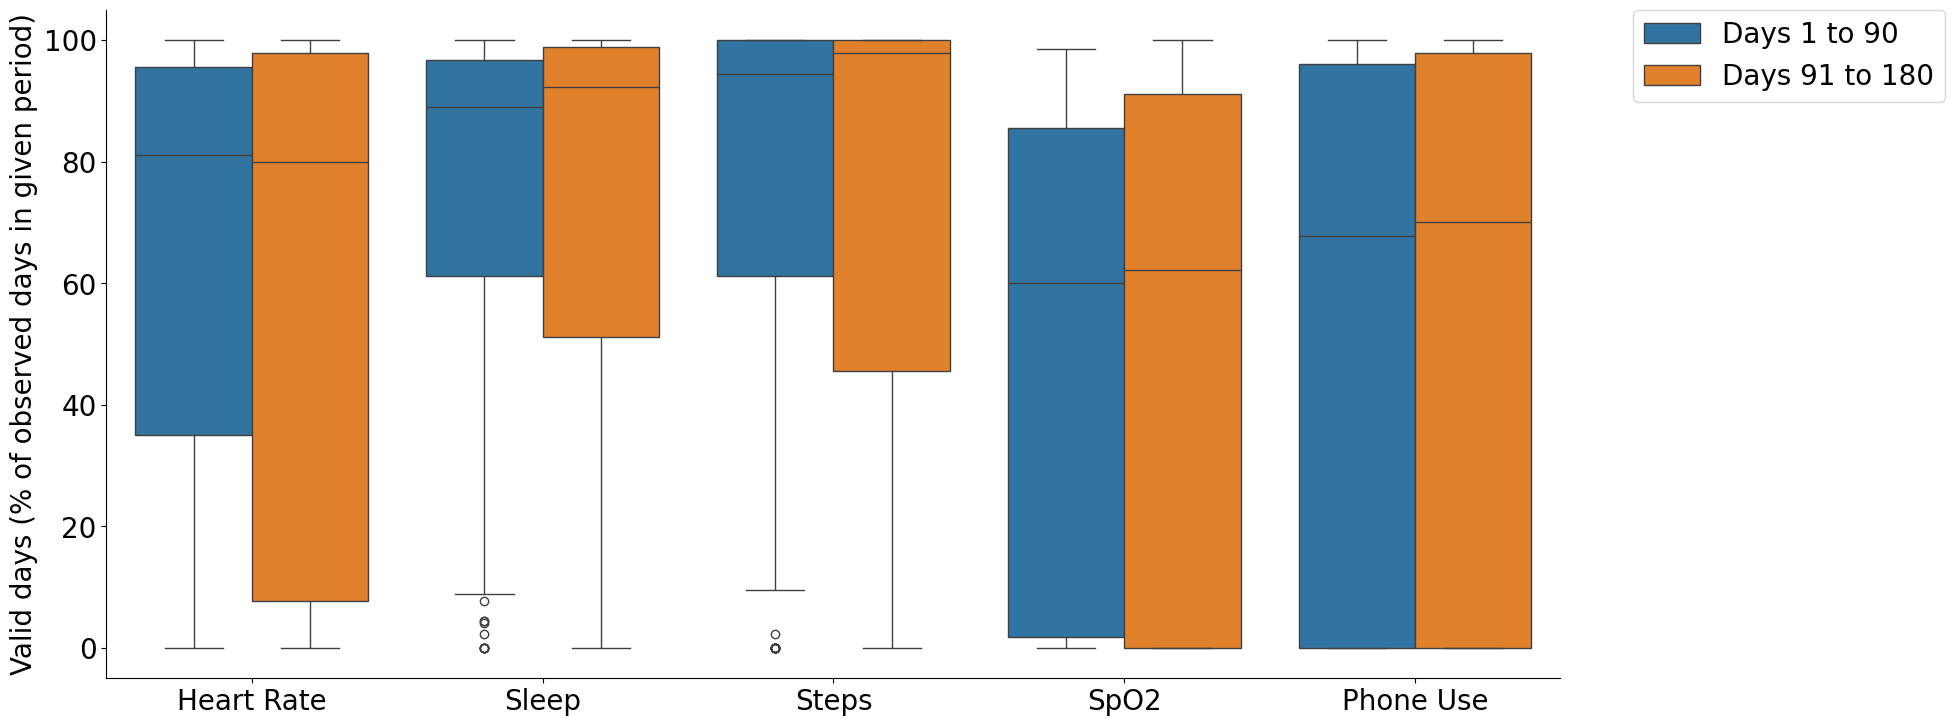

In [28]:
plt.rcParams['figure.figsize'] = (20, 8)
plt.rcParams['font.size'] = 20

sns.boxplot(df_, y='value', x='Data_Type', hue='Period')
#sns.stripplot(df_1, y='value', x='Data_Type', hue='Period', dodge=True, color='white', edgecolor='k', linewidth=1,palette=['white'],)
sns.despine()

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.ylabel('Valid days (% of observed days in given period)')
plt.xlabel('')

#plt.savefig('dist_box_plots.svg')

# Panel G

In [29]:
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter


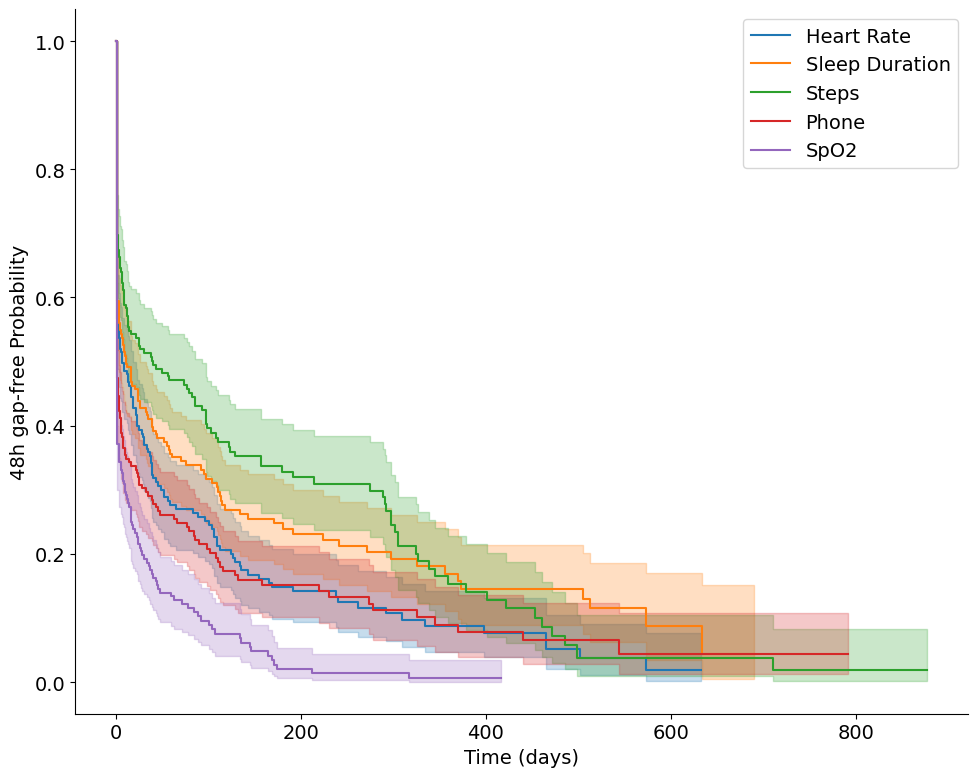

In [30]:
plt.rcParams.update({'font.size': 14})
plt.rcParams['figure.figsize'] = [10,8]
fig, ax = plt.subplots()

# Initialize KM fitter
kmf = KaplanMeierFitter()
df_=quality_df.copy()




df_['hr_gap']=~df_.first_hr_user_gap_48_date.isna()
df_['hr_gap_days']=(pd.to_datetime(df_.first_hr_user_gap_48_date)-pd.to_datetime(df_.min_date)).dt.days
df_.hr_gap_days=df_.hr_gap_days.fillna(df_.days_active)
kmf.fit(durations=df_.hr_gap_days,
        event_observed=df_.hr_gap)
kmf.plot_survival_function(ax=ax, ci_show=True, label='Heart Rate')

df_['sleep_gap']=~df_.first_sleep_user_gap_48_date.isna()
df_['sleep_gap_days']=(pd.to_datetime(df_.first_sleep_user_gap_48_date)-pd.to_datetime(df_.min_date)).dt.days
df_.sleep_gap_days=df_.sleep_gap_days.fillna(df_.days_active)
kmf.fit(durations=df_.sleep_gap_days,
        event_observed=df_.sleep_gap)
kmf.plot_survival_function(ax=ax, ci_show=True, label='Sleep Duration')

df_['steps_gap']=~df_.first_steps_user_gap_48_date.isna()
df_['steps_gap_days']=(pd.to_datetime(df_.first_steps_user_gap_48_date)-pd.to_datetime(df_.min_date)).dt.days
df_.steps_gap_days=df_.steps_gap_days.fillna(df_.days_active)
kmf.fit(durations=df_.steps_gap_days,
        event_observed=df_.steps_gap)
kmf.plot_survival_function(ax=ax, ci_show=True, label='Steps')


df_['phone_gap']=~df_.first_app_usage_user_gap_48_date.isna()
df_['phone_gap_days']=(pd.to_datetime(df_.first_app_usage_user_gap_48_date)-pd.to_datetime(df_.min_date)).dt.days
df_.phone_gap_days=df_.phone_gap_days.fillna(df_.days_active)
kmf.fit(durations=df_.phone_gap_days,
        event_observed=df_.phone_gap)
kmf.plot_survival_function(ax=ax, ci_show=True, label='Phone')


df_['spo2_gap']=~df_.first_spo2_user_gap_48_date.isna()
df_['spo2_gap_days']=(pd.to_datetime(df_.first_spo2_user_gap_48_date)-pd.to_datetime(df_.min_date)).dt.days
df_.spo2_gap_days=df_.spo2_gap_days.fillna(df_.days_active)
kmf.fit(durations=df_.spo2_gap_days,
        event_observed=df_.spo2_gap)
kmf.plot_survival_function(ax=ax, ci_show=True, label='SpO2')



# Annotate plot
plt.xlabel("Time (days)")
plt.ylabel("48h gap-free Probability")

## Add numbers at risk
#from lifelines.plotting import add_at_risk_counts
#add_at_risk_counts(kmf, ax=ax)

sns.despine()
plt.tight_layout()

#plt.show()
#plt.savefig('km.svg')

# Panel H

In [33]:
# Set the subjects order based on the HR data. Maintain the same order throughout
df_lasagna=pd.read_csv('../../../data/processed/data_completeness/lasagna_hr_valid_days_90.csv', index_col=0)
for i in df_lasagna.index.values:
    max_days=quality_df.loc[i].obs_valid_90
    cols_=[str(i) for i in range(max_days, 90)]
    df_lasagna.loc[i,cols_]=np.nan
    
# --- Count missing and invalid days per patient ---
order_=pd.DataFrame()
order_['missing_days'] = df_lasagna.isna().sum(axis=1)
order_['invalid_days'] = (df_lasagna == 0).sum(axis=1)
order_['valid_days'] = (df_lasagna == 1).sum(axis=1)
order_['pct_valid']= (order_['valid_days']) /(90-order_['missing_days'])

# --- Sort by missing first, then invalid ---
order_.loc[order_.valid_days==0,'pct_valid']=-1-(90*order_[order_.valid_days==0].missing_days.values)
order_ = order_.sort_values('pct_valid', ascending=False)

In [34]:
df_lasagna_steps=pd.read_csv('../../../data/processed/data_completeness/lasagna_steps_valid_days_90.csv', index_col=0)

In [35]:
for i in df_lasagna_steps.index.values:
    
    max_days=quality_df.loc[i].obs_valid_90

    cols_=[str(i) for i in range(max_days, 90)]
    df_lasagna_steps.loc[i,cols_]=np.nan

In [36]:
## Use same order_ as before
df_lasagna_steps=df_lasagna_steps.loc[order_.index.values]

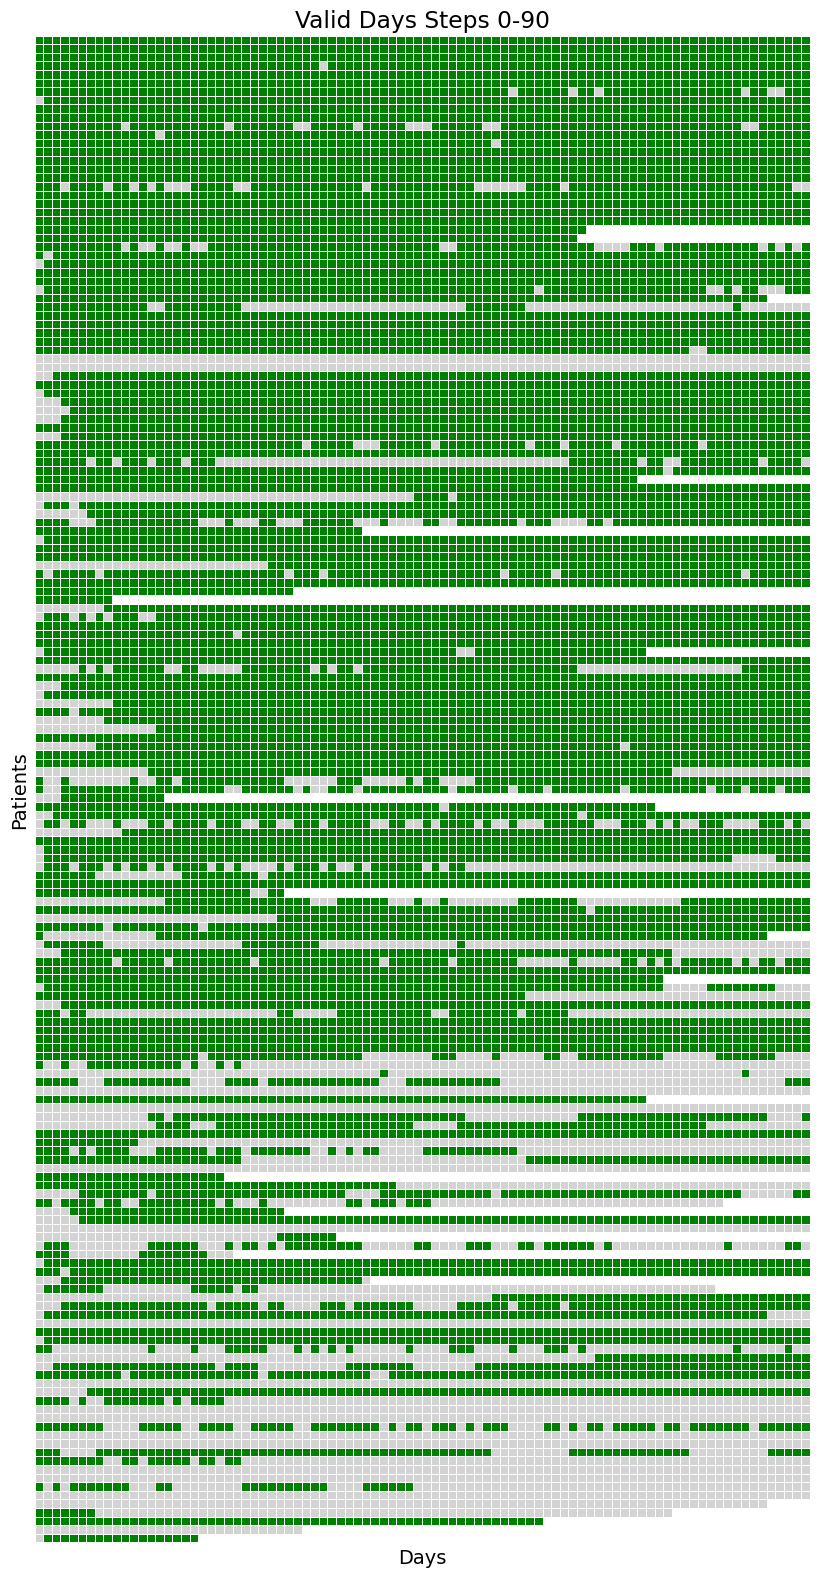

In [37]:
plt.rcParams.update({'font.size': 14})

# --- Mask where values are NaN ---
mask = df_lasagna_steps.isna()

# --- Create the heatmap ---
plt.figure(figsize=(10, 20))
sns.heatmap(
    df_lasagna_steps,
    cmap=sns.color_palette(["lightgray", "green"]),  # 0=gray, 1=green
    mask=mask,          # hides NaN cells
    cbar=False,         # optional, hides colorbar
    linewidths=0.5,
    linecolor='white'
)

# --- Make NaN appear as white ---
plt.imshow(mask, cmap="Greys", alpha=mask*0.0)  # optional tweak

plt.title("Valid Days Steps 0-90")
plt.xlabel("Days")
plt.ylabel("Patients")
plt.yticks([])
plt.xticks([])
#plt.savefig('Lasagna_steps_90.svg')

plt.show()


In [40]:
df_lasagna_steps180=pd.read_csv('../../../data/processed/data_completeness/lasagna_steps_valid_days_91_180.csv', index_col=0)

In [41]:
for i in df_lasagna_steps180.index.values:
    
    max_days=quality_df.loc[i].obs_valid_180

    cols_=[str(i) for i in range(max_days, 90)]
    df_lasagna_steps180.loc[i,cols_]=np.nan

In [42]:
## Use same order_ as before
df_lasagna_steps180=df_lasagna_steps180.loc[order_.index.values]

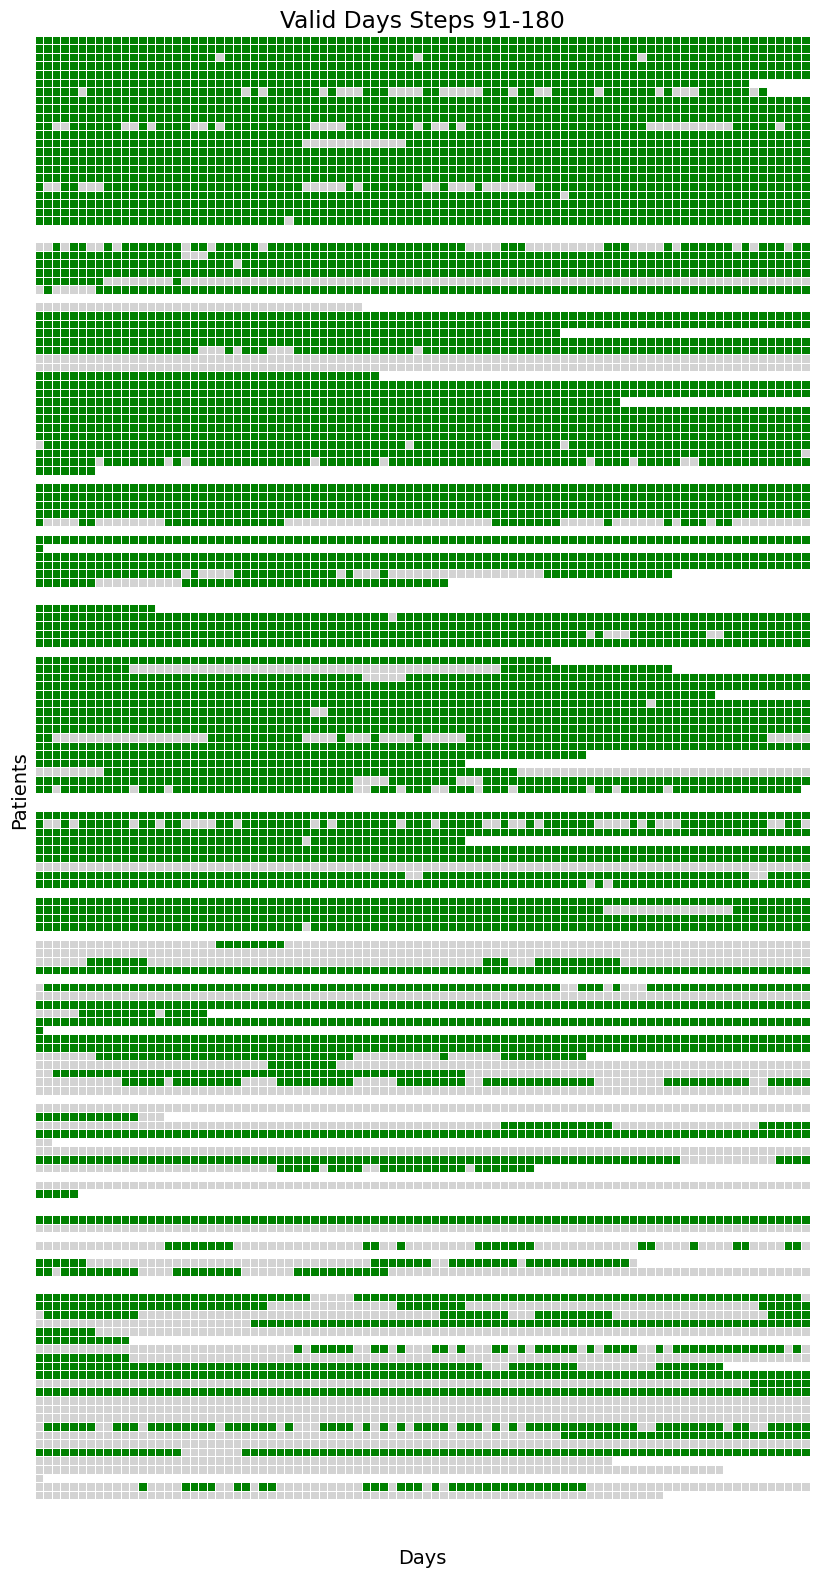

In [43]:
plt.rcParams.update({'font.size': 14})

# --- Mask where values are NaN ---
mask = df_lasagna_steps180.isna()

# --- Create the heatmap ---
plt.figure(figsize=(10, 20))
sns.heatmap(
    df_lasagna_steps180,
    cmap=sns.color_palette(["lightgray", "green"]),  # 0=gray, 1=green
    mask=mask,          # hides NaN cells
    cbar=False,         # optional, hides colorbar
    linewidths=0.5,
    linecolor='white'
)

# --- Make NaN appear as white ---
plt.imshow(mask, cmap="Greys", alpha=mask*0.0)  # optional tweak

plt.title("Valid Days Steps 91-180")
plt.xlabel("Days")
plt.ylabel("Patients")
plt.yticks([])
plt.xticks([])
#plt.savefig('Lasagna_Steps_180.svg')

plt.show()
